In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

import urllib.request

from IPython.display import display, Image


In [2]:
# If the folder "resources" exists, do nothing, else create the folder "resources"

resources_folder = "resources"

if os.path.isdir(resources_folder):
    print(f"Directory: `{resources_folder}` already exists")
else:
    print(f"Creating directory: `{resources_folder}`")
    os.makedirs(resources_folder)
    

Directory: `resources` already exists


In [3]:
# iruma_army_url = "https://github.com/cookieSensei/AI-tutorials/blob/main/iruma%20kun.PNG?raw=true"

# Creating CLI path to the image
iruma_army_img_path = os.path.join("resources", "iruma kun.PNG")
iruma_army_img_path

'resources/iruma kun.PNG'

In [4]:
iruma_army = cv2.imread(iruma_army_img_path)
iruma_army.shape

(977, 1363, 3)

In [5]:
def cv2_imshow(img_arr):
    """Function to visualize an image loaded using opencv.
    
    Parameters:
        img_arr: image array ing BGR format or say image loaded using opencv
    """
    
    img_arr = img_arr.copy()    
    image_rgb = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) 

    # plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)
    # plt.show()

<class 'numpy.ndarray'>
977 1363


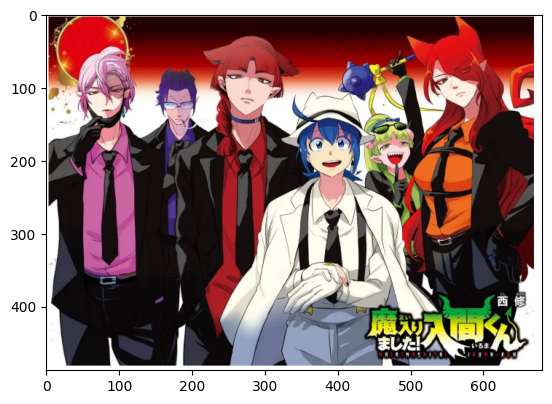

In [6]:
# To resize the image

height, width = iruma_army.shape[0], iruma_army.shape[1]

print(type(iruma_army)) # print the type of iruma_army image variable
print(height, width) # print height and width of the image

# OpenCV resize the image:
# cv2.resize(image, (tuple of new image's width and height), interpolation)
# interpolation is just some mathematical transformation
# interpolation has a default value as well,
# so don't worry about this argument
# your could exclude interpolation altogether
resized_small = cv2.resize(iruma_army, (int(width*0.5), int(height*0.5)),
                           interpolation=cv2.INTER_LINEAR)
cv2_imshow(resized_small)


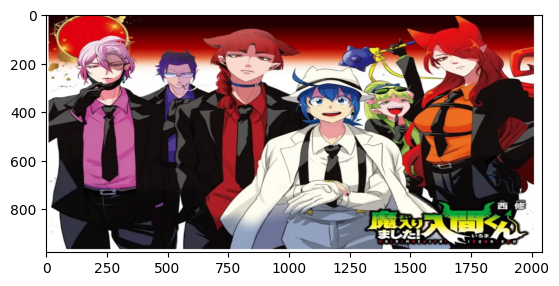

In [7]:
# To enlarge the image

resized_large = cv2.resize(iruma_army, (int(width*1.5), height),
                           interpolation=cv2.INTER_AREA)
cv2_imshow(resized_large)

# code that will write this enlarged image to output folder



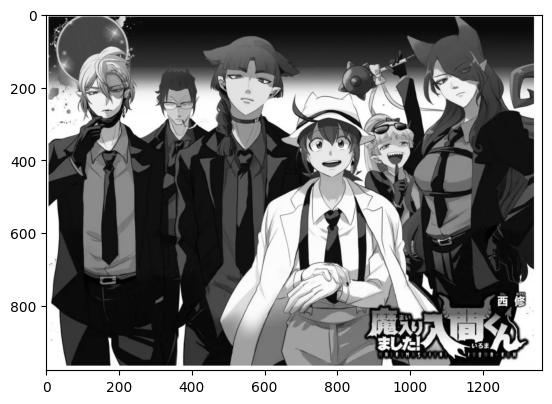

In [8]:

img = cv2.imread('resources/iruma kun.PNG')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   # Color change here.. bgr to greyscale
cv2_imshow(img)


In [9]:
# cookiesensei_img_url = "https://github.com/cookieSensei/AI-tutorials/blob/main/cookiesensei.jpg?raw=true"

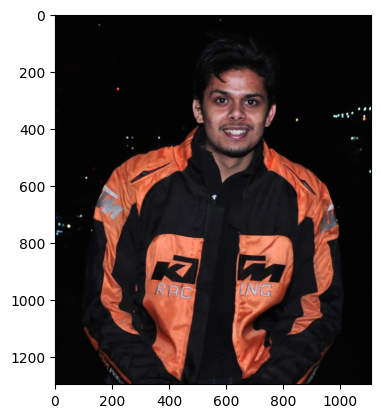

In [10]:
# OVERLAY

iruma_army = cv2.imread("resources/iruma kun.PNG")
cookiesensei = cv2.imread("resources/cookiesensei.jpg")

#########
# Crop cookiesensei image

height, width = cookiesensei.shape[0], cookiesensei.shape[1]
start_row, start_col = int(height*.05), int(width*.38)
end_row, end_col = int(height*0.70), int(width*0.75)

# specify the pixels where the image crop starts and ends
cookiesensei_cropped = cookiesensei[start_row:end_row, start_col:end_col]

cv2_imshow(cookiesensei_cropped)
###########



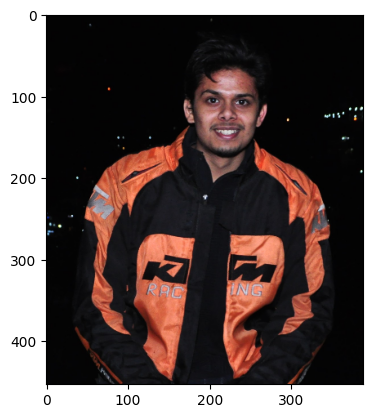

In [11]:
# Make cookiesensei image smaller
height_c, width_c = cookiesensei_cropped.shape[0], cookiesensei_cropped.shape[1]
resize_c = cv2.resize(cookiesensei_cropped, (int(width_c*0.35), int(height_c*0.35)),)
                      #interpolation=cv2.INTER_CUBIC)

cv2_imshow(resize_c)

iruma kun's army:  977 1363
cookiesensei's:  1296 1110


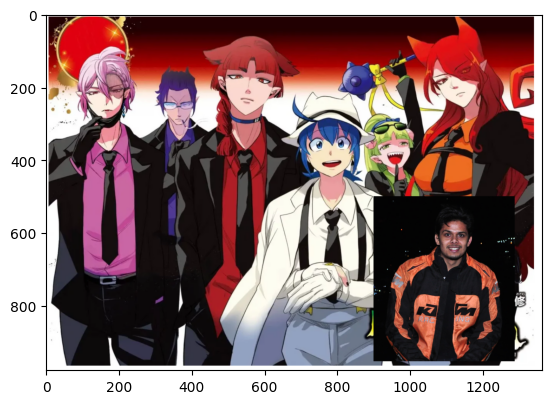

In [12]:
s_img = resize_c # we'll use resize_c as the smaller image
l_img = iruma_army # we'll use iruma_army as larger image

print("iruma kun's army: ", iruma_army.shape[0], iruma_army.shape[1])

print("cookiesensei's: ", height_c, width_c)

# fiddle around with the offset values to fit where you 
# want your smaller pic to be

x_offset = 900 # where to start the image crop on the x axis
y_offset = 500 # where to start the image crop on the y axis


# pixels starting from offset till the dimension of smaller image
# will be occupied by the smaller image

# subset the larger image by using []
# start with offset values of pixels
# till the offset + smaller image's pixels
# we replace those offset pixels with smaller image
l_img[y_offset:y_offset+s_img.shape[0], x_offset: x_offset+s_img.shape[1]] = s_img

cv2_imshow(l_img)


# Shape of an Image: Row pixels, Column pixels, Color channel

Therefore, `image.shape[0]` would yeild row pixels or more intuitively the height of an image.

`image.shape[1]` would yeild column pixels or more intuitively the width of an image.

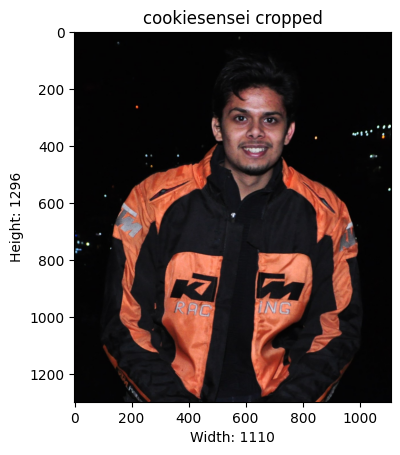

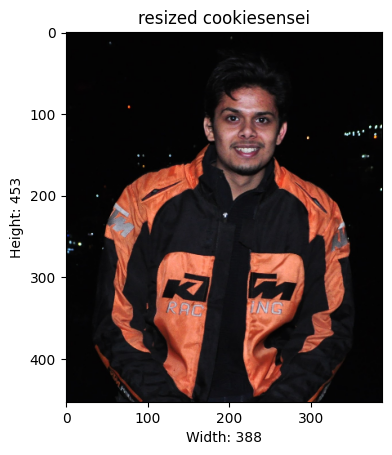

975 524


Text(0.5, 1.0, 'Image overlay')

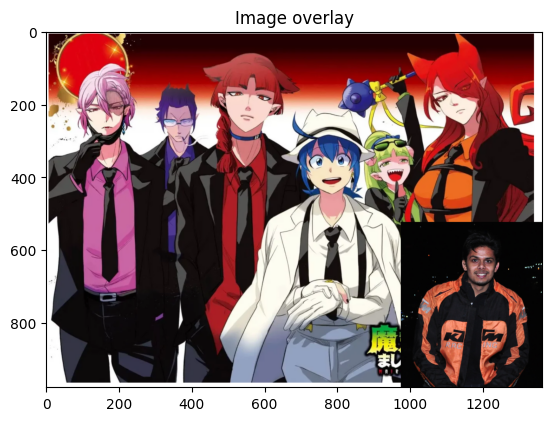

In [13]:
########### Lets properly select offset values

# The few lines of code will be the same repeated steps
iruma_army = cv2.imread("resources/iruma kun.PNG")
cookiesensei = cv2.imread("resources/cookiesensei.jpg")

height, width = cookiesensei.shape[0], cookiesensei.shape[1]
start_row, start_col = int(height*.05), int(width*.38)
end_row, end_col = int(height*0.70), int(width*0.75)

cookiesensei_cropped = cookiesensei[start_row:end_row, start_col:end_col]
height_c, width_c = cookiesensei_cropped.shape[0], cookiesensei_cropped.shape[1]

cv2_imshow(cookiesensei_cropped)
plt.title("cookiesensei cropped")
plt.xlabel(f"Width: {width_c}")
plt.ylabel(f"Height: {height_c}")
plt.show()

resize_c = cv2.resize(cookiesensei_cropped, (int(width_c*0.35), int(height_c*0.35)),)
cv2_imshow(resize_c)
plt.ylabel(f"Height: {resize_c.shape[0]}")
plt.xlabel(f"Width: {resize_c.shape[1]}")
plt.title("resized cookiesensei")
plt.show()

s_img = resize_c
l_img = iruma_army

# Just substract the smaller image's dimensions from the larger one
# This will be the ideal offset for bottom right fit offset values
x_offset = l_img.shape[1] - s_img.shape[1]
y_offset = l_img.shape[0] - s_img.shape[0]

print(x_offset, y_offset)

# pixels starting from offset till the dimension of smaller image
# will be occupied by the smaller image

l_img[y_offset:y_offset+s_img.shape[0], x_offset: x_offset+s_img.shape[1]] = s_img

cv2_imshow(l_img)
plt.title("Image overlay")

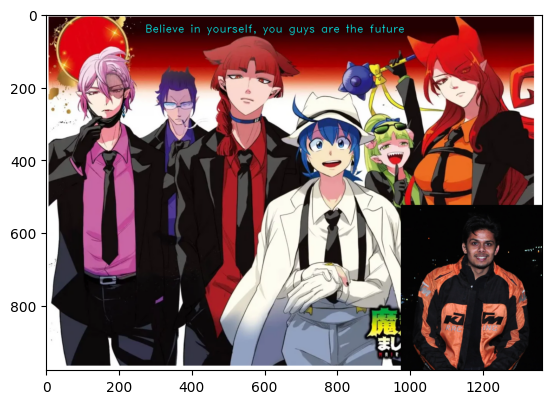

In [14]:
########### Display text on images

image_text_overlay = l_img

# The string to type onto the string
string_to_type = "Believe in yourself, you guys are the future"


image_text_overlay = cv2.putText(image_text_overlay, # image to use
                                 string_to_type, # string to type
                                 (int((image_text_overlay.shape[1])/5), 50),  # int((image_text_overlay.shape[0])/1.5)
                                 # tuple to pixel x and y values to write the string
                                 cv2.FONT_HERSHEY_DUPLEX, # just the font
                                 1, # scaling: less than one means to shrink the image and vice versa
                                 (255, 255, 0)) # BGR
cv2_imshow(image_text_overlay)


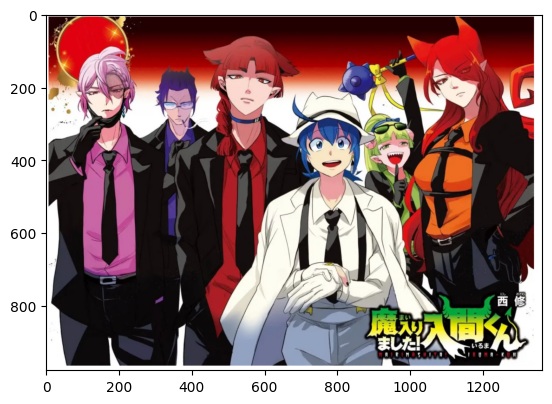

In [15]:
######################### Image segmentation using K-Means clustering

image = cv2.imread("resources/iruma kun.PNG")

# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2_imshow(image)
plt.show()


In [16]:


print(image.shape)
pixel_vals = image.reshape((-1, 3))
pixel_vals.shape # Means we need 3 slots to store RBG

pixel_vals[:5]

# (-1, 3) -1 here means change the first 1 dimensions in order to make space for 3 rgb values

# reshaping into (-1, 3) means we converted our pixel data to just a 2D array,
# so that we could use these pixels as predictors (X_labels)
# -1 in (-1, 3) says -1 will adjust the other dimensions accordingly

(977, 1363, 3)


array([[255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255],
       [255, 255, 255]], dtype=uint8)

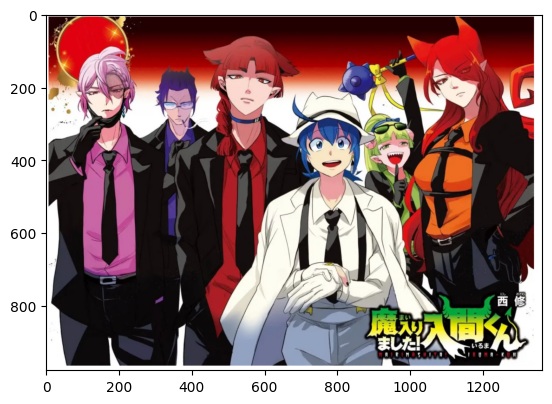

Clusters found. Format: BGR:
 [[159 139 131]
 [ 15  15 122]
 [ 10   9  22]
 [242 248 252]
 [142 108 198]
 [ 60 198 195]
 [180 192 215]
 [ 71  50  52]
 [ 34  49 203]
 [ 88  90  85]]
Labels created: [0 1 2 3 4 5 6 7 8 9]
Flattened image shape: (1331651, 3) 
Flattened image labels: (1331651, 1)


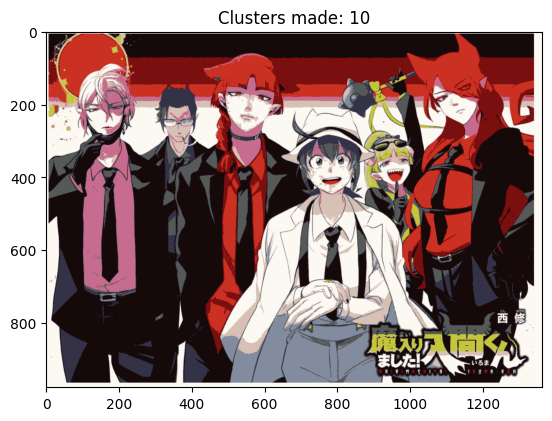

In [17]:
######################### Image segmentation using K-Means clustering

image = cv2.imread("resources/iruma kun.PNG")

# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2_imshow(image)
plt.show()

pixel_vals = image.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)


### Lets implements k-means now
# we'll take k=10 here

#the below line of code defines the criteria for the algorithm to stop running,
#which will happen if 100 iterations are run or the epsilon (which is the required accuracy)
#becomes 85%
criteria = (cv2.TERM_CRITERIA_EPS +cv2.TERM_CRITERIA_MAX_ITER,
            100,
            0.85)

k = 10

# arguments:
# 1: samples
# 2: k clusters
# 3: criteria
# 4: attempts
# 5: flags -  how initial centers are taken
compactness, labels, centers = cv2.kmeans(
    pixel_vals,
    k,
    None, # Best labels to store the cluster indices for every sample
    criteria, # criterion to stop
    10, # attemps
    cv2.KMEANS_RANDOM_CENTERS) # Flags: how initial centers are taken

# Convert data into 8-bit values

centers = np.uint8(centers)
print("Clusters found. Format: BGR:\n", centers)

print(f"Labels created: {np.unique(labels)}")

print(f"Flattened image shape: {pixel_vals.shape} \nFlattened image labels: {labels.shape}")

segmented_data = centers[labels.flatten()]

# Reshape data into the original image dimensions

segmented_image = segmented_data.reshape((image.shape))

cv2_imshow(segmented_image)
plt.title(f"Clusters made: {k}")
plt.show()

In [18]:
centers

array([[159, 139, 131],
       [ 15,  15, 122],
       [ 10,   9,  22],
       [242, 248, 252],
       [142, 108, 198],
       [ 60, 198, 195],
       [180, 192, 215],
       [ 71,  50,  52],
       [ 34,  49, 203],
       [ 88,  90,  85]], dtype=uint8)

In [19]:
labels.flatten()

array([3, 3, 3, ..., 3, 3, 3], dtype=int32)

In [20]:
centers[labels.flatten()]

array([[242, 248, 252],
       [242, 248, 252],
       [242, 248, 252],
       ...,
       [242, 248, 252],
       [242, 248, 252],
       [242, 248, 252]], dtype=uint8)

In [21]:
# segmented_data = centers[labels.flatten()]
segmented_data

array([[242, 248, 252],
       [242, 248, 252],
       [242, 248, 252],
       ...,
       [242, 248, 252],
       [242, 248, 252],
       [242, 248, 252]], dtype=uint8)

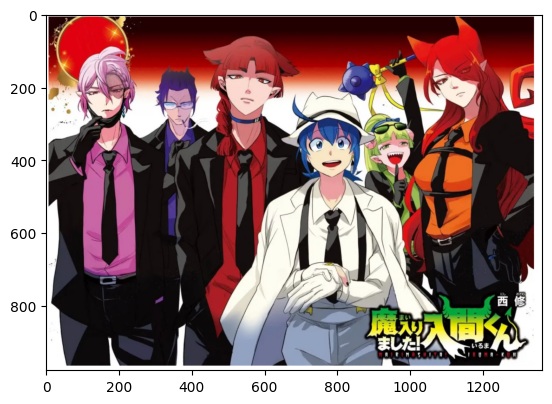

Clusters found. Format: BGR:
 [[147 148 187]
 [ 92  81  78]
 [ 28  37 175]
 [ 11  10  26]
 [238 245 250]]
Labels created: [0 1 2 3 4]
Flattened image shape: (1331651, 3) 
Flattened image labels: (1331651, 1)


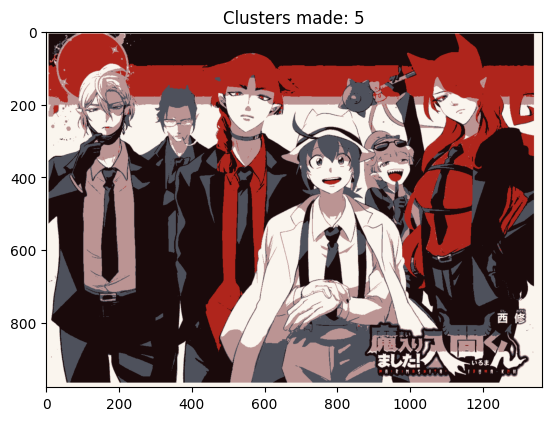

In [22]:
######################### Image segmentation using K-Means clustering

image = cv2.imread("resources/iruma kun.PNG")

# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2_imshow(image)
plt.show()

pixel_vals = image.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)


### Lets implements k-means now
# we'll take k=10 here

#the below line of code defines the criteria for the algorithm to stop running,
#which will happen if 100 iterations are run or the epsilon (which is the required accuracy)
#becomes 85%
criteria = (cv2.TERM_CRITERIA_EPS +cv2.TERM_CRITERIA_MAX_ITER,
            100,
            0.85)

k = 5

# arguments:
# 1: samples
# 2: k clusters
# 3: criteria
# 4: attempts
# 5: flags -  how initial centers are taken
compactness, labels, centers = cv2.kmeans(
    pixel_vals,
    k,
    None, # Best labels to store the cluster indices for every sample
    criteria, # criterion to stop
    10, # attemps
    cv2.KMEANS_RANDOM_CENTERS) # Flags: how initial centers are taken

# Convert data into 8-bit values

centers = np.uint8(centers)
print("Clusters found. Format: BGR:\n", centers)

print(f"Labels created: {np.unique(labels)}")

print(f"Flattened image shape: {pixel_vals.shape} \nFlattened image labels: {labels.shape}")

segmented_data = centers[labels.flatten()]

# Reshape data into the original image dimensions

segmented_image = segmented_data.reshape((image.shape))

cv2_imshow(segmented_image)
plt.title(f"Clusters made: {k}")
plt.show()

In [23]:
############# Image segmentation using color masking

# Lets first type how colors are represented as tuple values

#rgb
Red = 255, 0, 0
Green = 0, 255, 0
Blue = 0, 0, 255
Orange = 255, 165, 0
Purple = (128, 0, 128)
Light_Blue = (90, 70, 50)
Dark_Blue = 128, 255, 255
Light_Green = 40, 40, 40
Dark_Green = 70, 255, 255


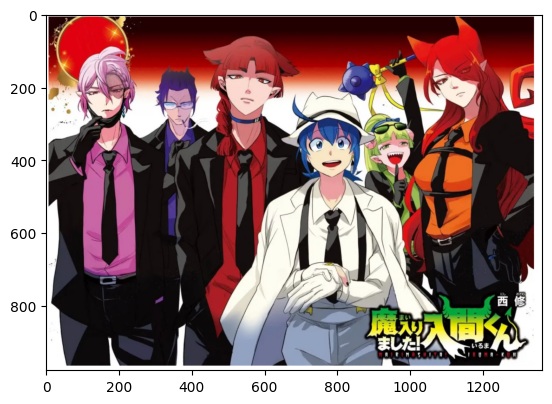

In [24]:
# Pre-process the image

img = cv2.imread("resources/iruma kun.PNG")
cv2_imshow(img)

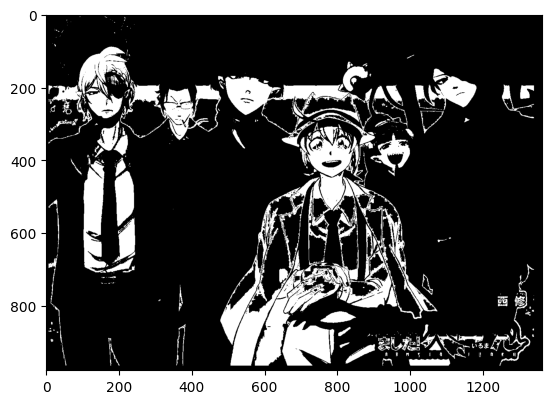

In [25]:
# By default opencv uses bgr format
# we can covert from bgr to rgb
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# But we can also convert to HSV
# HSV: Hue, Separation, Value
# Google hsv: you'll find visual explainations there
hsv_img = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV)

# Specify a range of colors:
# In this case: I specified a range of 0-255 on red
# 0-250 on green
# 150-255 on blue

# mask will tell us which pixels are going to be affected because of the 
# image transformation
mask = cv2.inRange(rgb_img, (0, 0, 150), (255, 250, 255))

cv2_imshow(mask)


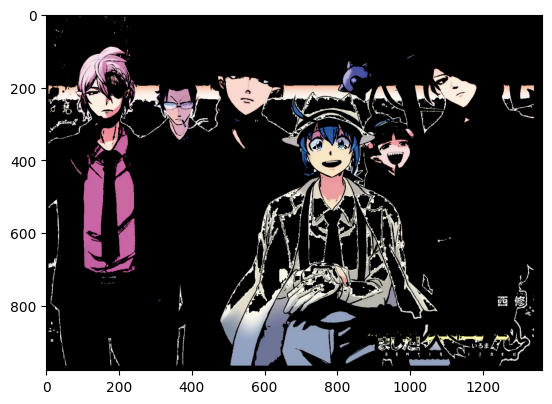

In [26]:
# Overlap two images with each other using a mask
# Google search: cv2.bitwise_and
# Look for some visual representations of how this works
result = cv2.bitwise_and(img, img, mask=mask)

cv2_imshow(result)

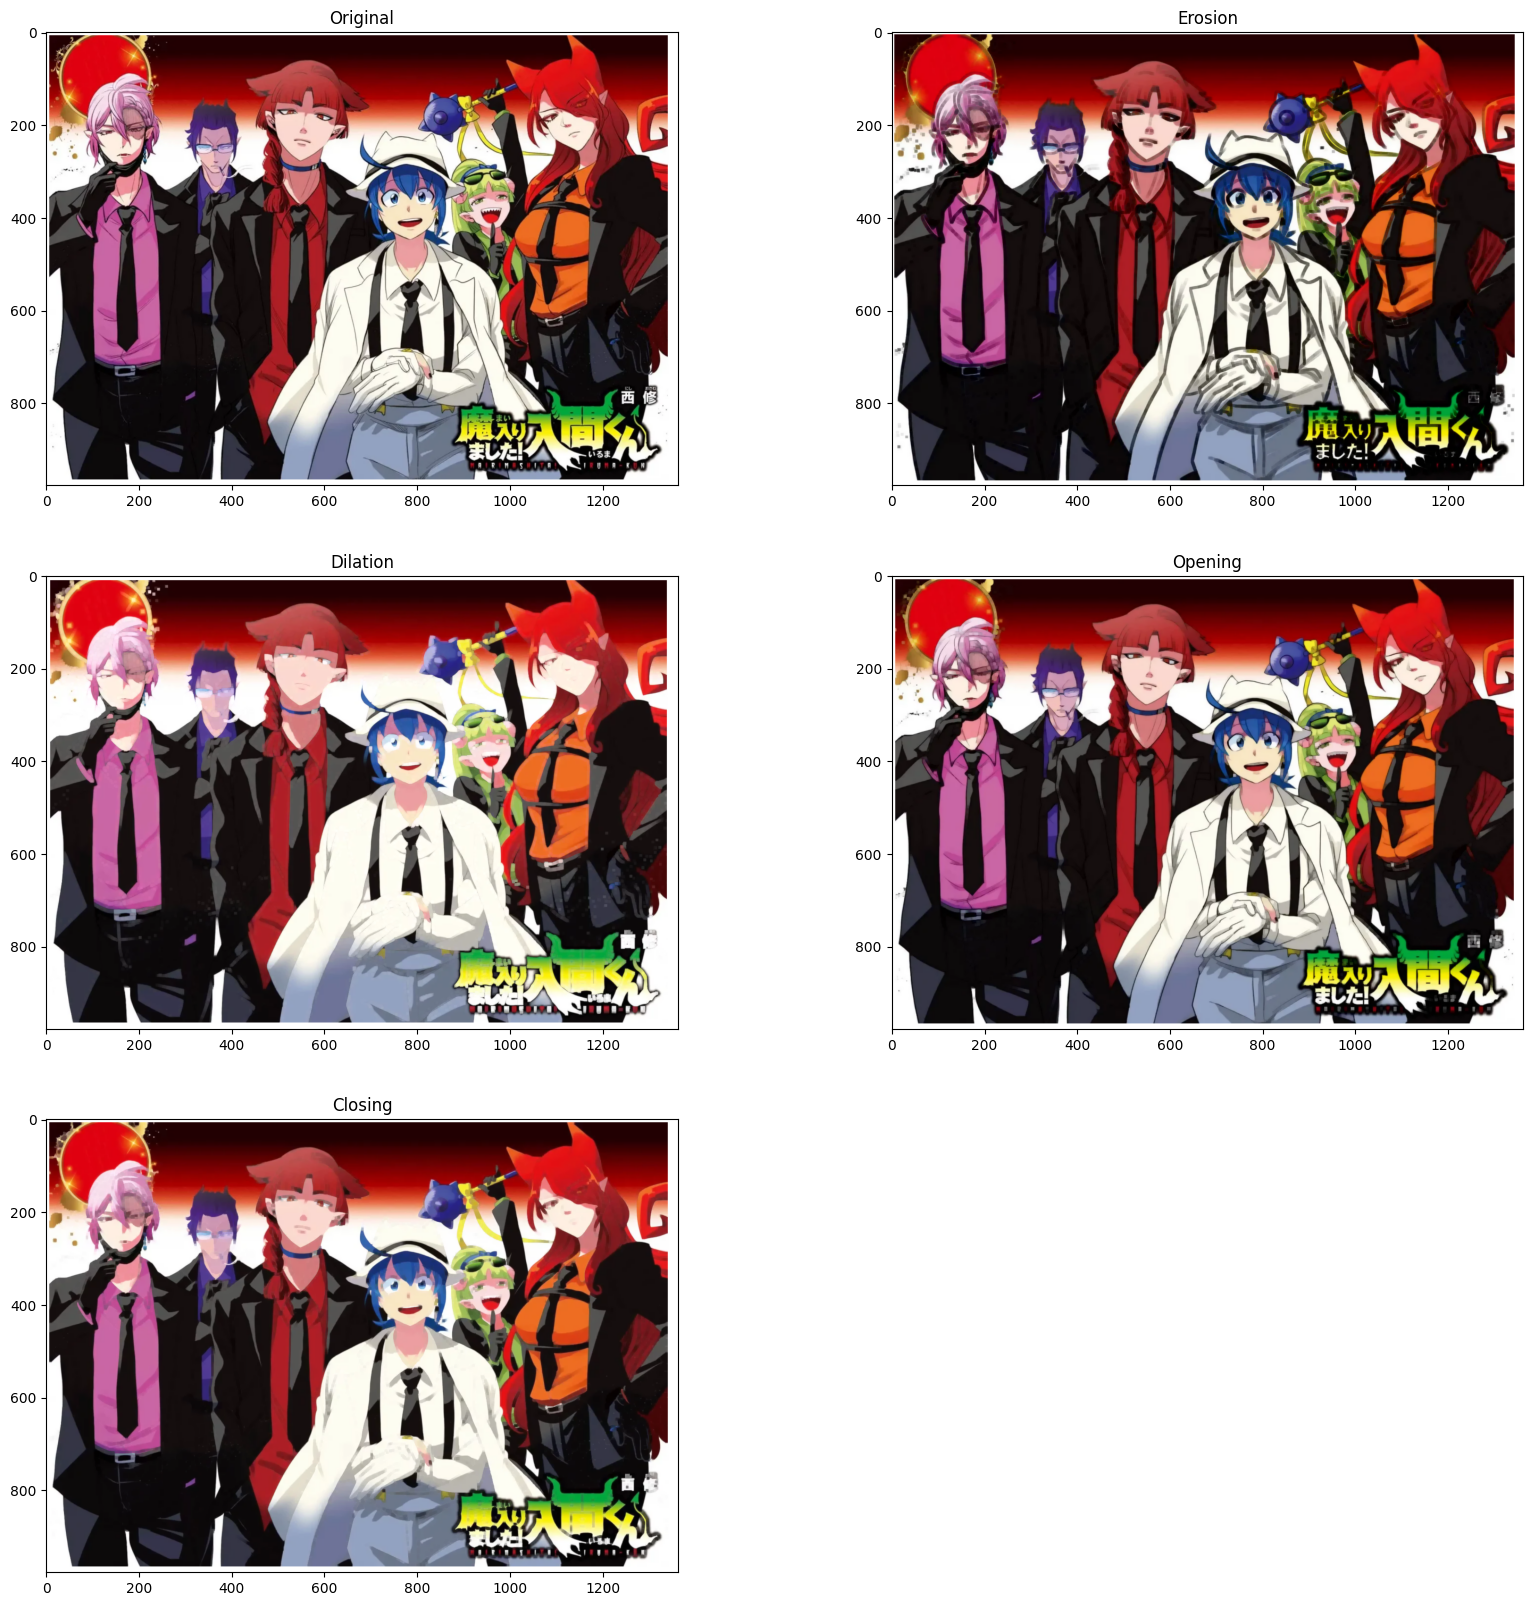

In [27]:
############# Dilation, Erosion, Opening and Closing


img = cv2.imread("resources/iruma kun.PNG")

# dilation = cv2.dilate(img, kernal, iterations=1)

# erosion = cv2.erode(image, kernel, iterations=1)

# opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

# closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 20))
plt.subplot(3, 2, 1)
plt.title("Original")
plt.imshow(img)


# Remember kernal: just a 5 by 5 matrix here
# np.uint8 says unsigned 8 bit integer
# don't worry about this yet
# For now, think of it as and encoding to decrease the unnecassary memory 
#used by the variable
kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(img, kernel, iterations=1)
plt.subplot(3, 2, 2)
plt.title("Erosion")
plt.imshow(erosion)


dilation = cv2.dilate(img, kernel, iterations=1)
plt.subplot(3, 2, 3)
plt.title("Dilation")
plt.imshow(dilation)


opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
plt.subplot(3, 2, 4)
plt.title("Opening")
plt.imshow(opening)


closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
plt.subplot(3, 2, 5)
plt.title("Closing")
plt.imshow(closing)


plt.show()

